# 🎮 Video Game Sales Analysis

## Market Trends, Regional Preferences & Statistical Testing

This project analyzes historical video game sales for the online store **Ice**.  
The objective is to identify patterns associated with commercial success and generate insights that could support marketing planning for 2017.

The workflow covers data preprocessing, exploratory data analysis, platform life cycles, regional market profiles, review-score relationships, genre performance, and statistical hypothesis testing.

> **Note:** Data for 2016 may be incomplete.

## 1. Setup & Data Loading

The dataset contains game releases, platforms, regional sales, critic and user scores, genres, and ESRB ratings.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/games.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-h1hmvhbc because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Dataset shape: 16,715 rows × 11 columns


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


## 2. Data Quality & Preprocessing

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [3]:
display(df.describe(include="all").T)
print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))
print(f"Fully duplicated rows: {df.duplicated().sum()}")

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,16713,11559,Need for Speed: Most Wanted,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,16715,31,PS2,2161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year_of_Release,16446.0,NaN,NaN,NaN,2006.484616,5.87705,1980.0,2003.0,2007.0,2010.0,2016.0
Genre,16713,12,Action,3369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NA_sales,16715.0,NaN,NaN,NaN,0.263377,0.813604,0.0,0.0,0.08,0.24,41.36
EU_sales,16715.0,NaN,NaN,NaN,0.14506,0.503339,0.0,0.0,0.02,0.11,28.96
JP_sales,16715.0,NaN,NaN,NaN,0.077617,0.308853,0.0,0.0,0.0,0.04,10.22
Other_sales,16715.0,NaN,NaN,NaN,0.047342,0.186731,0.0,0.0,0.01,0.03,10.57
Critic_Score,8137.0,NaN,NaN,NaN,68.967679,13.938165,13.0,60.0,71.0,79.0,98.0
User_Score,10014,96,tbd,2424,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


,missing_values
Name,2
Platform,0
Year_of_Release,269
Genre,2
NA_sales,0
EU_sales,0
JP_sales,0
Other_sales,0
Critic_Score,8578
User_Score,6701


Fully duplicated rows: 0


### Preprocessing decisions

- Column names are standardized to lowercase.
- `year_of_release` is converted to nullable integer because it represents calendar years and contains missing values.
- `user_score` contains the value `tbd` (“to be determined”). These observations do not provide a numeric score, so they are converted to `NaN` rather than imputed.
- Missing critic/user scores and ESRB ratings are retained because inventing review or rating values could distort the analysis.
- Missing game names, genres, and release years are not imputed because there is no reliable information from which to reconstruct them.
- A `total_sales` feature is created by summing sales across all regions.

In [4]:
df.columns = df.columns.str.lower()

df["year_of_release"] = pd.to_numeric(df["year_of_release"], errors="coerce").astype("Int64")
df["user_score"] = pd.to_numeric(df["user_score"], errors="coerce")

df["total_sales"] = (
    df["na_sales"] + df["eu_sales"] + df["jp_sales"] + df["other_sales"]
)

print(df.dtypes)
display(df[["name", "platform", "year_of_release", "user_score", "total_sales"]].head())

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
total_sales        float64
dtype: object


,name,platform,year_of_release,user_score,total_sales
0,Wii Sports,Wii,2006,8.0,82.54
1,Super Mario Bros.,NES,1985,NaN,40.24
2,Mario Kart Wii,Wii,2008,8.3,35.52
3,Wii Sports Resort,Wii,2009,8.0,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,NaN,31.38


## 3. Releases Over Time

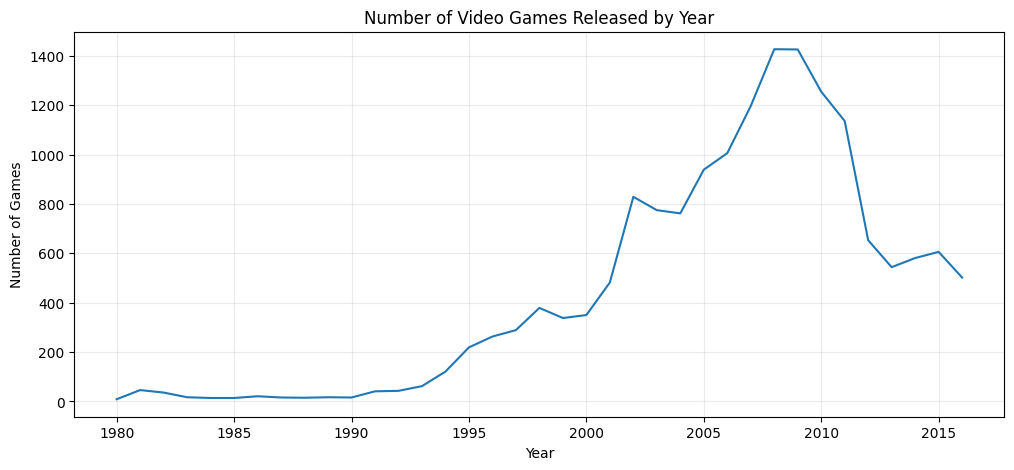

Peak release year: 2008 (1427 games)


In [5]:
games_per_year = df["year_of_release"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(games_per_year.index.astype(int), games_per_year.values)
plt.title("Number of Video Games Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.grid(alpha=0.25)
plt.show()

peak_year = int(games_per_year.idxmax())
print(f"Peak release year: {peak_year} ({games_per_year.max()} games)")

The earliest years contain relatively few releases and are less representative of the modern market.  
Release volume expands strongly from the 1990s and peaks during the late 2000s, supporting the use of a more recent window for 2017 planning.

## 4. Platform Sales & Life Cycles

,total_sales
platform,
PS2,1255.77
X360,971.42
PS3,939.65
Wii,907.51
DS,806.12
PS,730.86
GBA,317.85
PS4,314.14
PSP,294.05


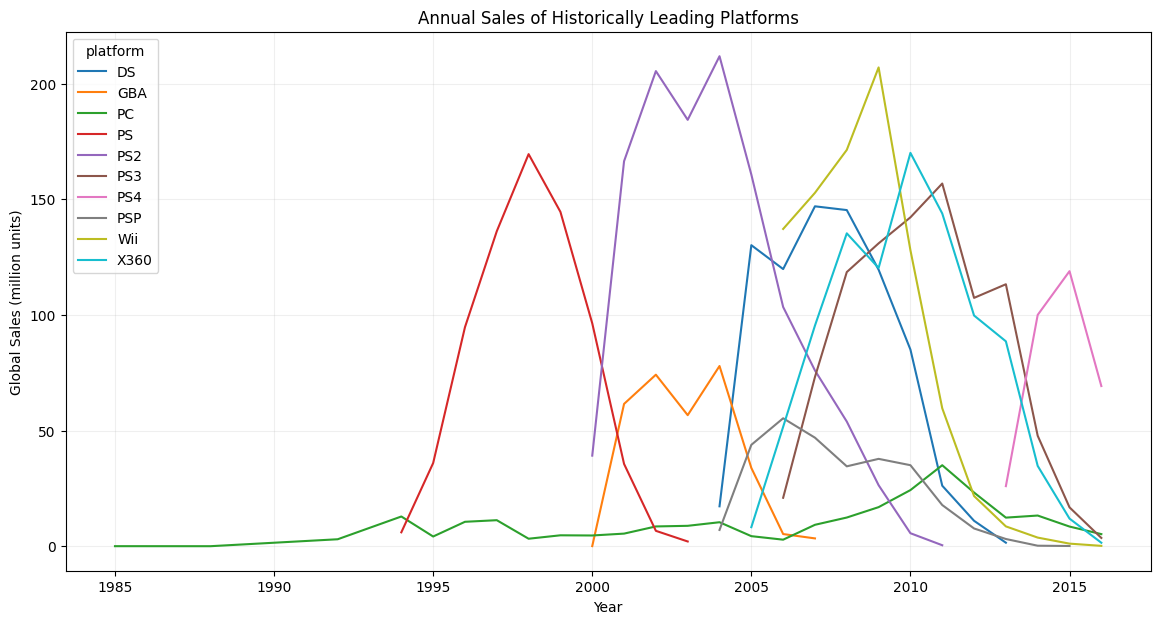

In [6]:
platform_sales = df.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
display(platform_sales.head(10).to_frame("total_sales"))

top_platforms = platform_sales.head(10).index
platform_sales_year = (
    df[df["platform"].isin(top_platforms)]
    .pivot_table(index="year_of_release", columns="platform", values="total_sales", aggfunc="sum")
)

platform_sales_year.plot(figsize=(14, 7))
plt.title("Annual Sales of Historically Leading Platforms")
plt.xlabel("Year")
plt.ylabel("Global Sales (million units)")
plt.grid(alpha=0.2)
plt.show()

The historical curves show that platforms typically have a limited commercial life cycle: they emerge, grow, peak, and then decline as newer hardware generations gain adoption.  
For a campaign planned in December 2016, very old platform generations would therefore add limited predictive value.

Based on these patterns, the analysis below focuses on **2012–2016**, a recent window that captures the current console generation and its transition period.

In [7]:
df_recent = df[df["year_of_release"].between(2012, 2016)].copy()

recent_platform_sales = (
    df_recent.groupby("platform")["total_sales"].sum().sort_values(ascending=False)
)
display(recent_platform_sales.to_frame("2012_2016_sales"))

recent_trends = (
    df_recent.pivot_table(
        index="year_of_release",
        columns="platform",
        values="total_sales",
        aggfunc="sum"
    )
)

top_recent = recent_platform_sales.head(10).index
display(recent_trends[top_recent].round(2))

,2012_2016_sales
platform,
PS4,314.14
PS3,288.79
X360,236.54
3DS,194.61
XOne,159.32
WiiU,82.19
PC,62.65
PSV,49.18
Wii,35.37


platform,PS4,PS3,X360,3DS,XOne,WiiU,PC,PSV,Wii,DS
year_of_release,,,,,,,,,,
2012,NaN,107.36,99.74,51.36,NaN,17.56,23.22,16.19,21.71,11.01
2013,25.99,113.25,88.58,56.57,18.96,21.65,12.38,10.59,8.59,1.54
2014,100.00,47.76,34.74,43.76,54.07,22.03,13.28,11.90,3.75,NaN
2015,118.90,16.82,11.96,27.78,60.14,16.35,8.52,6.25,1.14,NaN
2016,69.25,3.60,1.52,15.14,26.15,4.60,5.25,4.25,0.18,NaN


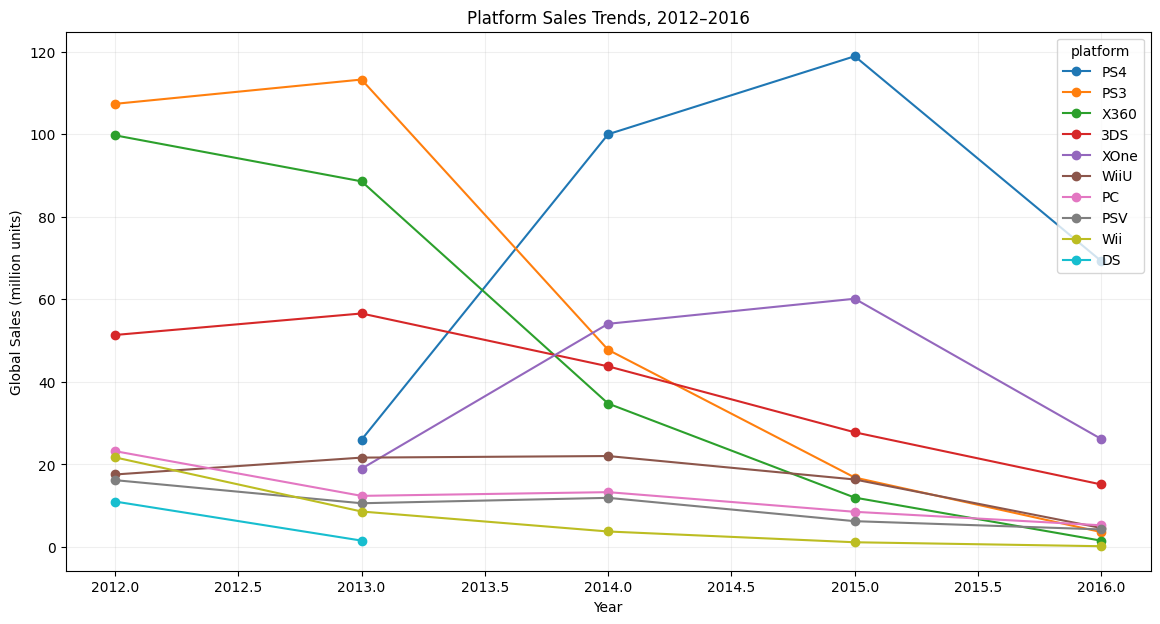

In [8]:
recent_trends[top_recent].plot(figsize=(14, 7), marker="o")
plt.title("Platform Sales Trends, 2012–2016")
plt.xlabel("Year")
plt.ylabel("Global Sales (million units)")
plt.grid(alpha=0.2)
plt.show()

PS4 and Xbox One become important during the selected period, while older-generation systems such as PS3 and Xbox 360 decline.  
Because 2016 is explicitly described as potentially incomplete, the final-year decline should not be interpreted as a complete market-year result.

## 5. Sales Distribution by Platform

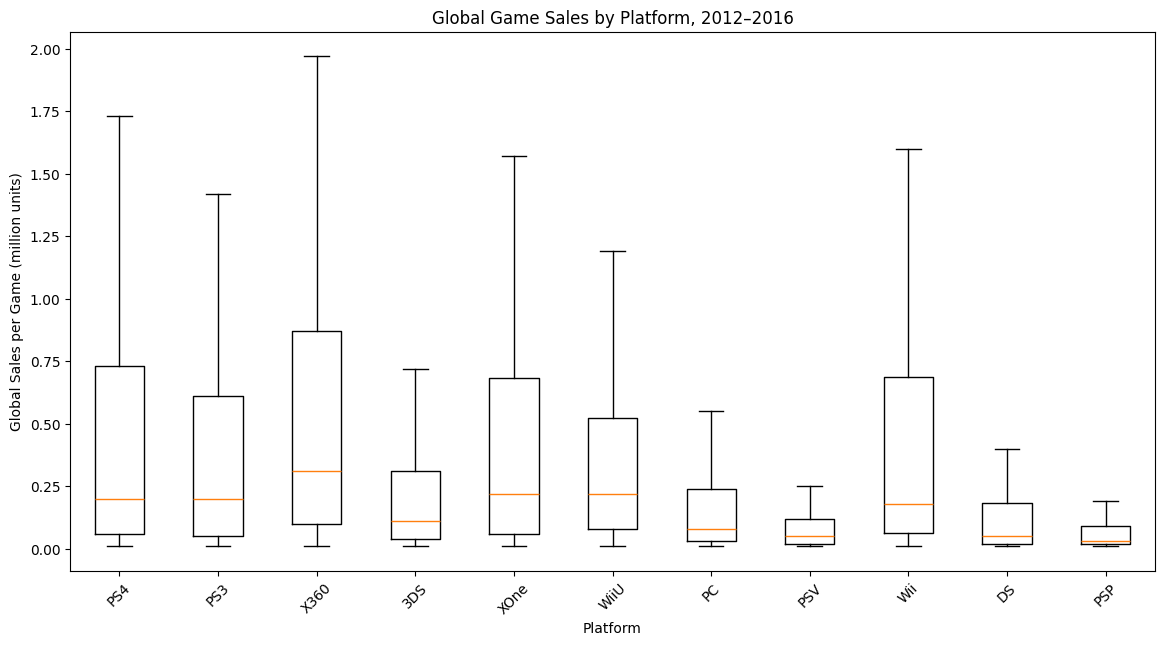

,count,mean,median
platform,,,
X360,292,0.810,0.31
PS4,392,0.801,0.20
Wii,54,0.655,0.18
XOne,247,0.645,0.22
PS3,493,0.586,0.20
WiiU,147,0.559,0.22
3DS,396,0.491,0.11
DS,31,0.405,0.05
PC,250,0.251,0.08


In [9]:
platform_order = recent_platform_sales.index

data_for_box = [
    df_recent.loc[df_recent["platform"] == p, "total_sales"].dropna()
    for p in platform_order
]

plt.figure(figsize=(14, 7))
plt.boxplot(data_for_box, labels=platform_order, showfliers=False)
plt.title("Global Game Sales by Platform, 2012–2016")
plt.xlabel("Platform")
plt.ylabel("Global Sales per Game (million units)")
plt.xticks(rotation=45)
plt.show()

platform_summary = (
    df_recent.groupby("platform")["total_sales"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(platform_summary.round(3))

Sales distributions are strongly right-skewed: most games sell relatively modest volumes while a smaller number of blockbuster titles generate much larger sales.  
This makes the median especially useful alongside the mean when comparing typical game performance across platforms.

## 6. Reviews vs. Sales — PS4

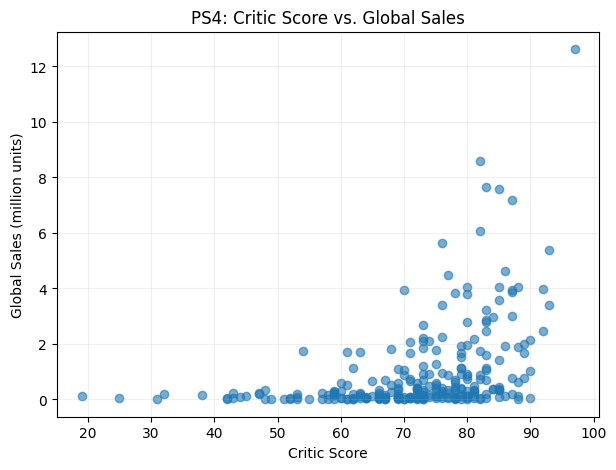

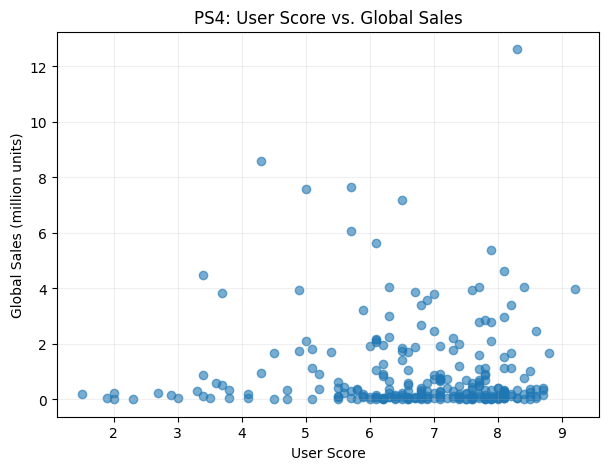

PS4 critic score correlation: 0.407
PS4 user score correlation:   -0.032


In [10]:
ps4 = df_recent[df_recent["platform"] == "PS4"].copy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ps4["critic_score"], ps4["total_sales"], alpha=0.6)
ax.set_title("PS4: Critic Score vs. Global Sales")
ax.set_xlabel("Critic Score")
ax.set_ylabel("Global Sales (million units)")
ax.grid(alpha=0.2)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ps4["user_score"], ps4["total_sales"], alpha=0.6)
ax.set_title("PS4: User Score vs. Global Sales")
ax.set_xlabel("User Score")
ax.set_ylabel("Global Sales (million units)")
ax.grid(alpha=0.2)
plt.show()

critic_corr = ps4["critic_score"].corr(ps4["total_sales"])
user_corr = ps4["user_score"].corr(ps4["total_sales"])
print(f"PS4 critic score correlation: {critic_corr:.3f}")
print(f"PS4 user score correlation:   {user_corr:.3f}")

For PS4, critic scores show a clearer positive relationship with sales than user scores.  
Correlation does not establish causation, but it helps quantify whether stronger reviews tend to accompany stronger commercial performance.

In [11]:
comparison_platforms = ["PS4", "XOne", "PS3", "3DS", "PC"]
corr_rows = []

for platform in comparison_platforms:
    subset = df_recent[df_recent["platform"] == platform]
    corr_rows.append({
        "platform": platform,
        "critic_sales_corr": subset["critic_score"].corr(subset["total_sales"]),
        "user_sales_corr": subset["user_score"].corr(subset["total_sales"]),
        "games": len(subset)
    })

display(pd.DataFrame(corr_rows).set_index("platform").round(3))

,critic_sales_corr,user_sales_corr,games
platform,,,
PS4,0.407,-0.032,392
XOne,0.417,-0.069,247
PS3,0.331,-0.005,493
3DS,0.321,0.198,396
PC,0.237,-0.122,250


## 7. Genre Performance

,games,total_sales,median_sales,mean_sales
genre,,,,
Action,1031,441.12,0.120,0.428
Shooter,235,304.73,0.440,1.297
Role-Playing,370,192.80,0.140,0.521
Sports,268,181.07,0.240,0.676
Misc,192,85.04,0.120,0.443
Platform,85,61.00,0.210,0.718
Racing,115,53.50,0.140,0.465
Fighting,109,44.49,0.130,0.408
Simulation,80,35.12,0.120,0.439


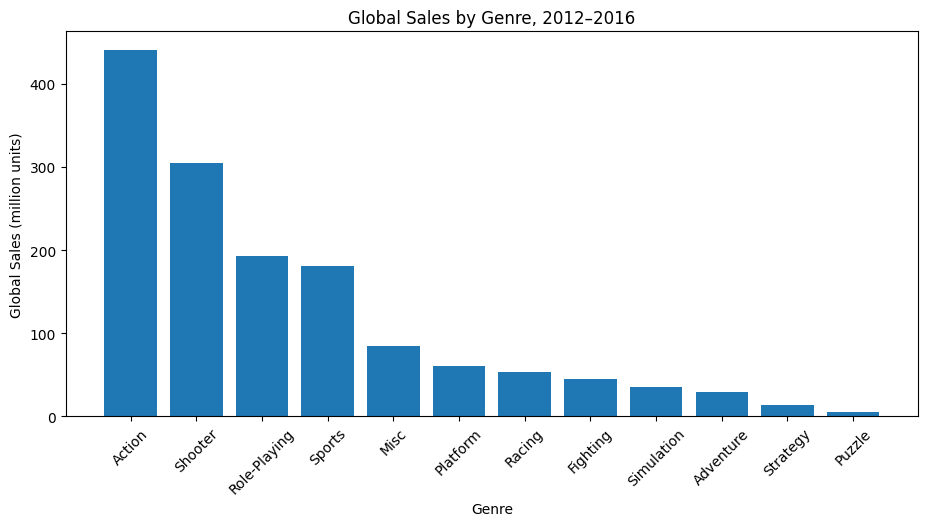

In [12]:
genre_summary = (
    df_recent.groupby("genre")["total_sales"]
    .agg(games="count", total_sales="sum", median_sales="median", mean_sales="mean")
    .sort_values("total_sales", ascending=False)
)
display(genre_summary.round(3))

plt.figure(figsize=(11, 5))
plt.bar(genre_summary.index, genre_summary["total_sales"])
plt.title("Global Sales by Genre, 2012–2016")
plt.xlabel("Genre")
plt.ylabel("Global Sales (million units)")
plt.xticks(rotation=45)
plt.show()

Total sales identify the genres that contribute the most market volume, while median and mean sales help distinguish broad genre popularity from the effect of a few blockbuster titles.

## 8. Regional Market Profiles

In [13]:
regions = {
    "North America": "na_sales",
    "Europe": "eu_sales",
    "Japan": "jp_sales"
}

for region, sales_col in regions.items():
    total = df_recent[sales_col].sum()

    top_platforms_region = (
        df_recent.groupby("platform")[sales_col].sum().sort_values(ascending=False).head(5)
    )
    top_genres_region = (
        df_recent.groupby("genre")[sales_col].sum().sort_values(ascending=False).head(5)
    )

    print(f"\n--- {region} ---")
    platform_profile = pd.DataFrame({
        "sales": top_platforms_region,
        "market_share_%": top_platforms_region / total * 100
    })
    display(platform_profile.round(2))

    genre_profile = pd.DataFrame({
        "sales": top_genres_region,
        "market_share_%": top_genres_region / total * 100
    })
    display(genre_profile.round(2))


--- North America ---


,sales,market_share_%
platform,,
X360,140.05,23.70
PS4,108.74,18.40
PS3,103.38,17.49
XOne,93.12,15.76
3DS,55.31,9.36


,sales,market_share_%
genre,,
Action,177.84,30.09
Shooter,144.77,24.50
Sports,81.53,13.80
Role-Playing,64.00,10.83
Misc,38.19,6.46



--- Europe ---


,sales,market_share_%
platform,,
PS4,141.09,27.84
PS3,106.86,21.08
X360,74.52,14.70
XOne,51.59,10.18
3DS,42.64,8.41


,sales,market_share_%
genre,,
Action,159.34,31.44
Shooter,113.47,22.39
Sports,69.09,13.63
Role-Playing,48.53,9.58
Racing,27.29,5.38



--- Japan ---


,sales,market_share_%
platform,,
3DS,87.79,45.59
PS3,35.29,18.32
PSV,21.04,10.93
PS4,15.96,8.29
WiiU,13.01,6.76


,sales,market_share_%
genre,,
Role-Playing,65.44,33.98
Action,52.80,27.42
Misc,12.86,6.68
Simulation,10.41,5.41
Fighting,9.44,4.90


Regional preferences are not identical. North America and Europe share several major platforms and genres, while Japan shows a more distinct profile, especially in platform and genre concentration.  
This suggests that a single global marketing strategy may overlook meaningful regional differences.

,North America,Europe,Japan
rating,,,
E,114.37,113.03,28.33
E10+,75.70,55.37,8.19
M,231.57,193.96,21.20
T,66.02,52.96,26.02
Unknown,103.31,91.50,108.84


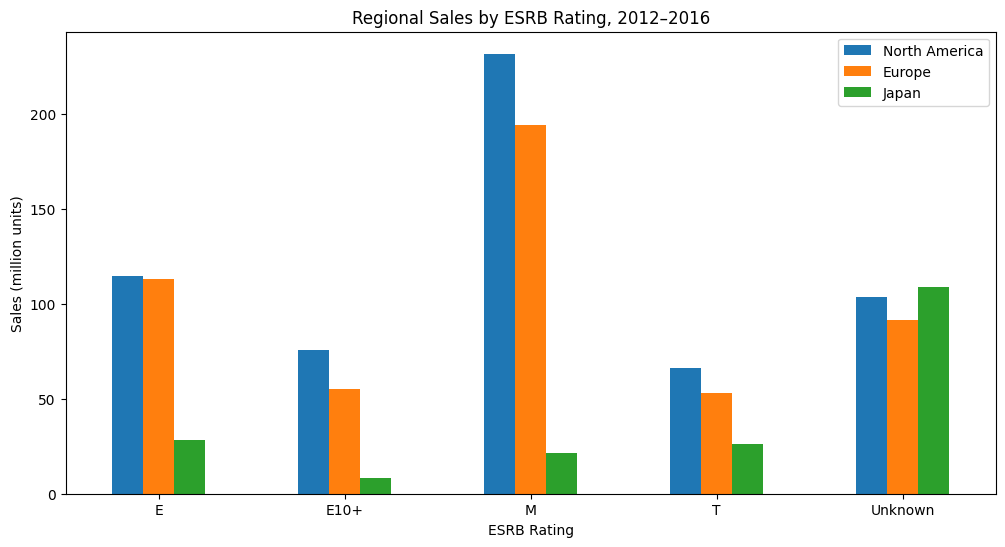

In [14]:
rating_data = df_recent.copy()
rating_data["rating"] = rating_data["rating"].fillna("Unknown")

rating_profiles = {}
for region, sales_col in regions.items():
    profile = (
        rating_data.groupby("rating")[sales_col]
        .sum()
        .sort_values(ascending=False)
    )
    rating_profiles[region] = profile

rating_table = pd.DataFrame(rating_profiles).fillna(0)
display(rating_table.round(2))

rating_table.plot(kind="bar", figsize=(12, 6))
plt.title("Regional Sales by ESRB Rating, 2012–2016")
plt.xlabel("ESRB Rating")
plt.ylabel("Sales (million units)")
plt.xticks(rotation=0)
plt.show()

ESRB sales distributions differ by region, but this should be interpreted as an association rather than a causal effect.  
The `Unknown` group is kept visible because removing unrated games could materially distort regional comparisons, particularly in markets where ESRB coverage is less representative.

## 9. Statistical Hypothesis Testing

A significance level of **α = 0.05** is used for both tests.

### Test 1 — Xbox One vs. PC user ratings
- **H₀:** Mean user ratings for Xbox One and PC games are equal.
- **H₁:** Mean user ratings for Xbox One and PC games are different.

### Test 2 — Action vs. Sports user ratings
- **H₀:** Mean user ratings for Action and Sports games are equal.
- **H₁:** Mean user ratings for Action and Sports games are different.

Independent two-sample Welch's t-tests are used because the groups are independent and equal population variances are not assumed.

In [15]:
alpha = 0.05

xone_scores = df_recent.loc[
    (df_recent["platform"] == "XOne") & df_recent["user_score"].notna(),
    "user_score"
]
pc_scores = df_recent.loc[
    (df_recent["platform"] == "PC") & df_recent["user_score"].notna(),
    "user_score"
]

t1, p1 = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print("TEST 1 — Xbox One vs. PC")
print(f"Xbox One: n={len(xone_scores)}, mean={xone_scores.mean():.3f}")
print(f"PC:       n={len(pc_scores)}, mean={pc_scores.mean():.3f}")
print(f"t-statistic={t1:.3f}, p-value={p1:.6f}")
print("Decision:", "Reject H0" if p1 < alpha else "Fail to reject H0")

TEST 1 — Xbox One vs. PC
Xbox One: n=182, mean=6.521
PC:       n=206, mean=6.429
t-statistic=0.600, p-value=0.548954
Decision: Fail to reject H0


In [16]:
action_scores = df_recent.loc[
    (df_recent["genre"] == "Action") & df_recent["user_score"].notna(),
    "user_score"
]
sports_scores = df_recent.loc[
    (df_recent["genre"] == "Sports") & df_recent["user_score"].notna(),
    "user_score"
]

t2, p2 = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print("TEST 2 — Action vs. Sports")
print(f"Action: n={len(action_scores)}, mean={action_scores.mean():.3f}")
print(f"Sports: n={len(sports_scores)}, mean={sports_scores.mean():.3f}")
print(f"t-statistic={t2:.3f}, p-value={p2:.6f}")
print("Decision:", "Reject H0" if p2 < alpha else "Fail to reject H0")

TEST 2 — Action vs. Sports
Action: n=523, mean=6.825
Sports: n=195, mean=5.456
t-statistic=9.903, p-value=0.000000
Decision: Reject H0


## 10. General Conclusion

This analysis shows that the video game market is highly dynamic and shaped by platform life cycles, genre preferences, regional differences, and a small number of high-selling titles.

For planning a 2017 campaign, the 2012–2016 period provides a more relevant view of the contemporary market than the full historical dataset. New-generation platforms such as PS4 and Xbox One became commercially important during this window, while older platforms were already declining.

Review analysis indicates that professional critic scores tend to have a stronger relationship with sales than user scores for PS4, although review scores alone cannot explain commercial success.

Regional analysis also demonstrates that consumer preferences differ meaningfully across North America, Europe, and Japan. Platform, genre, and ESRB-rating patterns should therefore be considered regionally rather than assumed to be globally uniform.

Finally, the hypothesis tests provide a statistical basis for comparing user-rating behavior across platforms and genres. Together, these findings illustrate how exploratory analysis and statistical inference can support more informed marketing decisions while acknowledging that 2016 data may be incomplete.